# Lesson 3 — Partial Dependence Plots (PDPs)
Curso: Machine Learning Explainability (Kaggle)
Dataset: medical_readmissions
Formato: Study + Reference + Hands‑on

---

## 1) Objetivos da Lesson

Nesta lesson, você vai:

- Entender o que é um **Partial Dependence Plot (PDP)**.
- Ver como o PDP responde à pergunta:
  > “Como cada feature afeta as previsões do modelo?”
- Gerar PDPs 1D e 2D para um modelo de regressão ou classificação.
- Interpretar o formato das curvas (linear, não linear, em U, etc.).
- Relacionar PDPs com o que você já viu em **Permutation Importance**.

---

## 2) Glossário Técnico

- **Partial Dependence Plot (PDP):** gráfico que mostra como a previsão média muda quando variamos uma feature, mantendo as outras constantes.
- **PDP 1D:** gráfico de uma feature só (eixo X = feature, eixo Y = previsão média).
- **PDP 2D:** gráfico com duas features (eixos X e Y = features, cores = previsão média).
- **Marginalização:** média das previsões sobre todas as outras features.
- **Interação:** quando o efeito de uma feature depende do valor de outra.

---

## 3) Mini‑Referência (API Style)

- `sklearn.ensemble.RandomForestRegressor` ou `RandomForestClassifier`
  - `fit(X, y)`
  - `predict(X)`

- `sklearn.model_selection.train_test_split`
  - `train_test_split(X, y, random_state=...)`

- `sklearn.inspection.PartialDependenceDisplay`
  - `PartialDependenceDisplay.from_estimator(model, X, [feature])`
  - `PartialDependenceDisplay.from_estimator(model, X, [(feature_1, feature_2)])`

- `matplotlib.pyplot`
  - `plt.show()`

---

## 4) Introdução Conceitual

Na lesson anterior (Permutation Importance), você respondeu:

> “Quais features são importantes para o modelo?”

Agora, a pergunta muda para:

> “**Como** cada feature afeta as previsões?”

O **Partial Dependence Plot (PDP)** responde exatamente isso:

- mostra a forma da relação entre uma feature e a previsão do modelo;
- mantém as demais features constantes (em média).

Aqui, vamos aplicar PDPs ao dataset **medical_readmissions**, para entender:

- como variáveis clínicas influenciam a probabilidade ou o número de readmissões;
- como duas variáveis juntas podem interagir nas previsões do modelo.

---

## 5) Implementação passo a passo

A partir daqui, o foco é **mão na massa**.

### 5.1. Imports e carregamento dos dados

In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

Ajuste o caminho abaixo para o local onde você salvou o dataset
`medical_readmissions` (por exemplo: `data/raw/medical_readmissions.csv`).

In [2]:
import os

possible_paths = [
    "data/raw/medical_readmissions.csv",
    "../data/raw/medical_readmissions.csv",
    "../../data/raw/medical_readmissions.csv",
]

data_path = None

for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("medical_readmissions.csv não encontrado em nenhum caminho conhecido.")

print("Usando dataset em:", data_path)

data = pd.read_csv(data_path)

Usando dataset em: ../data/raw/medical_readmissions.csv


Agora precisamos definir:
- a coluna alvo (`target_col`)
- quais colunas serão usadas como features numéricas.

Ajuste `target_col` conforme o seu dataset.

In [3]:
# Defina aqui o nome da coluna alvo do seu dataset
# Exemplo: "readmitted_30_days", "readmitted", "num_readmissions", etc.
target_col = "readmitted"  # <-- ajuste este nome

if target_col not in data.columns:
    raise ValueError(f"Coluna alvo '{target_col}' não encontrada no dataset.")

y = data[target_col]

# Selecionar apenas colunas numéricas como candidatas a features
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remover a coluna alvo da lista de features
numeric_features = [c for c in numeric_cols if c != target_col]

if len(numeric_features) < 2:
    raise ValueError("Poucas features numéricas encontradas. Verifique o dataset.")

print("Features numéricas disponíveis:", numeric_features)

# Para fins de exemplo, vamos usar as 4 primeiras features numéricas
base_features = numeric_features[:4]
print("Base features usadas nos PDPs:", base_features)

X = data[base_features]

Features numéricas disponíveis: ['age', 'time_in_hospital', 'time_in_hospital_scaled', 'num_procedures', 'num_medications', 'lab_tests', 'bmi_estimate', 'socks_owned']
Base features usadas nos PDPs: ['age', 'time_in_hospital', 'time_in_hospital_scaled', 'num_procedures']


Dependendo do tipo de problema:
- Se `y` for contínuo → usamos `RandomForestRegressor`
- Se `y` for categórico/binário → usamos `RandomForestClassifier`

Aqui vamos detectar automaticamente.

In [4]:
is_classification = y.dtype == "object" or y.nunique() <= 10

if is_classification:
    # Converter alvo para binário/categórico se necessário
    y_encoded = y.astype("category").cat.codes
    ModelClass = RandomForestClassifier
    print("Detectado problema de CLASSIFICAÇÃO.")
else:
    y_encoded = y
    ModelClass = RandomForestRegressor
    print("Detectado problema de REGRESSÃO.")

train_X, val_X, train_y, val_y = train_test_split(
    X, y_encoded, random_state=1
)

model = ModelClass(n_estimators=100, random_state=1)
model.fit(train_X, train_y)

print("Modelo treinado com sucesso.")

Detectado problema de CLASSIFICAÇÃO.
Modelo treinado com sucesso.


### 5.2. PDP 1D — Entendendo o formato da curva

Vamos começar com a primeira feature da lista `base_features`.

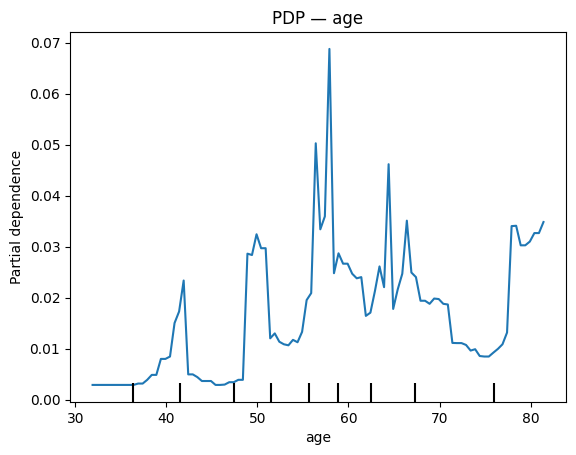

In [5]:
feat_name = base_features[0]

PartialDependenceDisplay.from_estimator(
    model,
    val_X,
    [feat_name],
)
plt.title(f"PDP — {feat_name}")
plt.show()

**Reflexão rápida:**

- A previsão aumenta ou diminui conforme essa feature cresce?
- A relação parece linear, em degraus, em U, saturada?

### 5.3. PDP 1D para todas as base_features

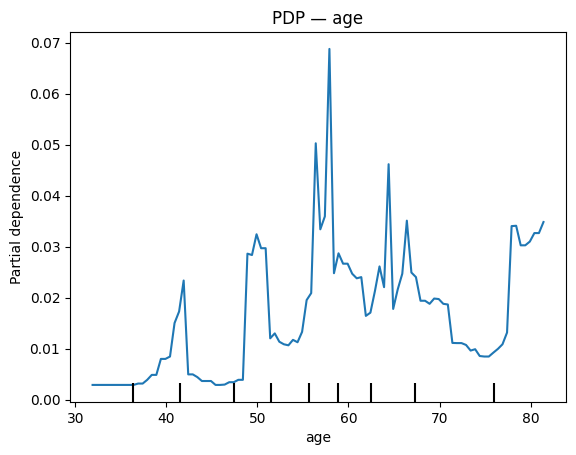

/home/moacir/projects/ml/envs/kaggle-ml/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


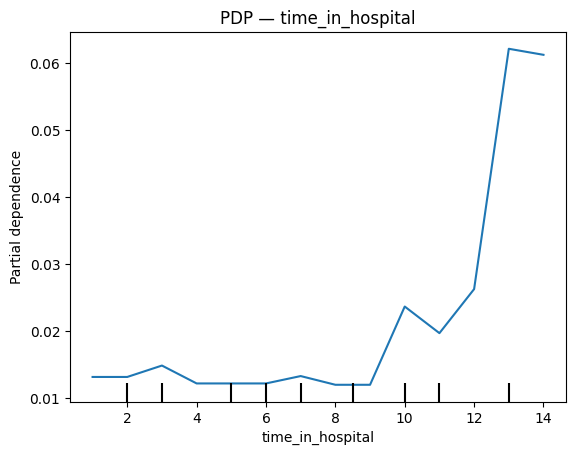

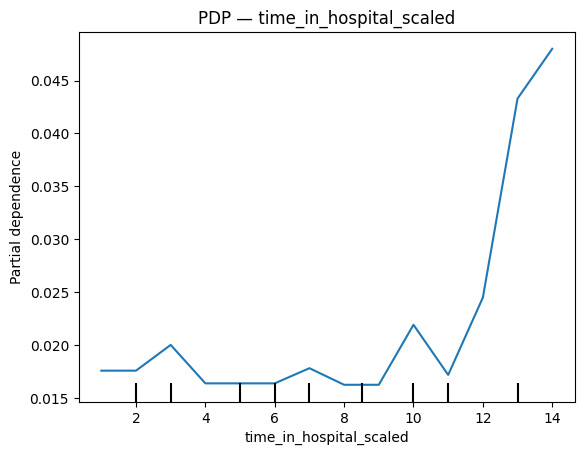

/home/moacir/projects/ml/envs/kaggle-ml/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


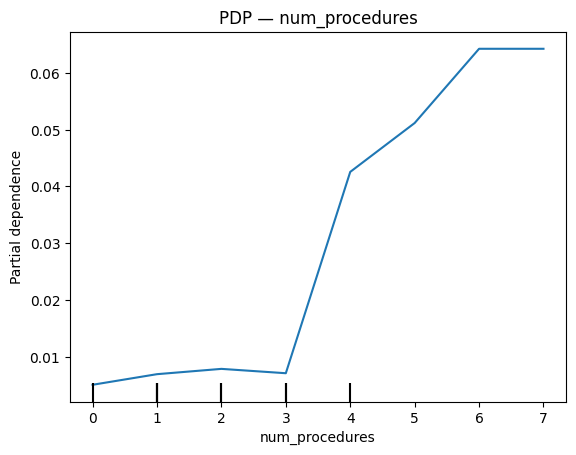

In [6]:
for feat_name in base_features:
    PartialDependenceDisplay.from_estimator(
        model,
        val_X,
        [feat_name],
    )
    plt.title(f"PDP — {feat_name}")
    plt.show()

Observe:

- Quais features têm curvas mais inclinadas?
- Alguma parece não afetar muito a previsão?
- Alguma mostra comportamento não linear (curvas, platôs, etc.)?

### 5.4. PDP 2D — Interação entre duas features

Agora vamos gerar um **PDP 2D** para visualizar a interação entre
as duas primeiras features numéricas.

/home/moacir/projects/ml/envs/kaggle-ml/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


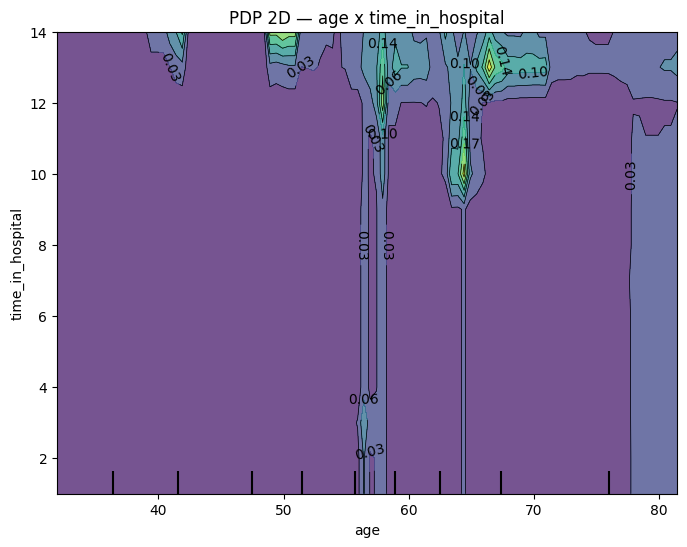

In [7]:
if len(base_features) >= 2:
    feat_pair = (base_features[0], base_features[1])

    fig, ax = plt.subplots(figsize=(8, 6))

    PartialDependenceDisplay.from_estimator(
        model,
        val_X,
        [feat_pair],
        ax=ax,
    )

    plt.title(f"PDP 2D — {feat_pair[0]} x {feat_pair[1]}")
    plt.show()
else:
    print("Menos de 2 features numéricas disponíveis para PDP 2D.")

**Interpretação sugerida:**

- Regiões mais claras indicam previsões mais altas.
- Regiões mais escuras indicam previsões mais baixas.
- Veja se o efeito de uma feature depende do valor da outra.

### 5.5. Experimento sintético — controlando o formato do PDP

Para fixar o conceito, vamos criar um dataset sintético em que:

- `X1` e `X2` são features em 

\[-2, 2];
- `y` é definido de forma controlada;
- usamos Random Forest para aprender o padrão;
- geramos o PDP de `X1`.

/home/moacir/projects/ml/envs/kaggle-ml/lib/python3.12/site-packages/sklearn/inspection/_plot/partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


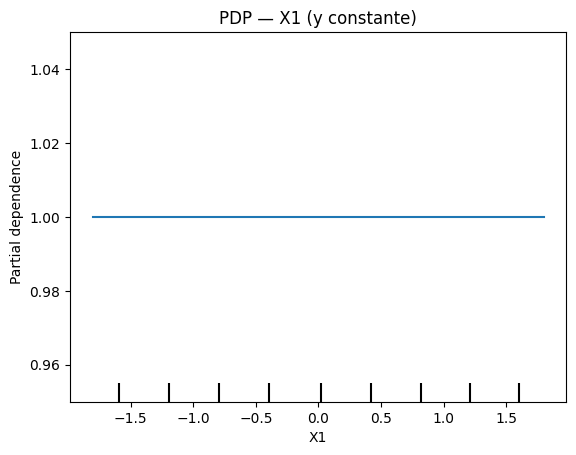

In [8]:
from numpy.random import rand

n_samples = 20_000

X1 = 4 * rand(n_samples) - 2  # intervalo [-2, 2]
X2 = 4 * rand(n_samples) - 2  # intervalo [-2, 2]

# Exemplo 1: y constante (PDP deve ser quase flat)
y_const = np.ones(n_samples)

df_synth = pd.DataFrame({"X1": X1, "X2": X2, "y": y_const})
X_synth = df_synth[["X1", "X2"]]

model_synth = RandomForestRegressor(n_estimators=30, random_state=1)
model_synth.fit(X_synth, df_synth["y"])

PartialDependenceDisplay.from_estimator(
    model_synth,
    X_synth,
    ["X1"],
)
plt.title("PDP — X1 (y constante)")
plt.show()

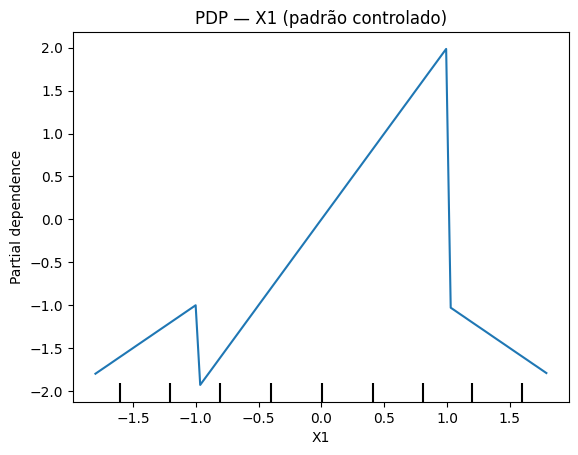

In [9]:
# Exemplo 2: y com padrão controlado em função de X1
X1 = 4 * rand(n_samples) - 2
X2 = 4 * rand(n_samples) - 2

y_pattern = np.where(
    (X1 >= -1) & (X1 <= 1),
    2 * X1,          # inclinação positiva em [-1, 1]
    -1 * np.abs(X1), # inclinação negativa fora desse intervalo
)

df_synth2 = pd.DataFrame({"X1": X1, "X2": X2, "y": y_pattern})
X_synth2 = df_synth2[["X1", "X2"]]

model_synth2 = RandomForestRegressor(n_estimators=50, random_state=1)
model_synth2.fit(X_synth2, df_synth2["y"])

PartialDependenceDisplay.from_estimator(
    model_synth2,
    X_synth2,
    ["X1"],
)
plt.title("PDP — X1 (padrão controlado)")
plt.show()

Esse tipo de experimento ajuda a entender **como o PDP reflete o padrão aprendido pelo modelo**:

- Se o modelo aprende uma relação linear, o PDP tende a ser uma reta.
- Se o modelo aprende uma relação não linear, o PDP mostra curvas, U, degraus, etc.

---

## 6) Observações pedagógicas do Copilot

- PDP é uma ferramenta **global**: mostra o efeito médio, não o efeito em um indivíduo específico.
- Ele complementa **Permutation Importance**:
  - Permutation Importance → “o que importa”
  - PDP → “como importa”
- No contexto de **medical_readmissions**, PDP pode mostrar:
  - como tempo de internação, número de procedimentos, idade, etc. afetam a previsão;
  - se há regiões de risco (por exemplo, certos intervalos de uma variável).
- PDPs 2D são especialmente úteis para visualizar **interações** entre variáveis clínicas.

---

## 7) Conclusão

Nesta lesson, você:

- viu o conceito de **Partial Dependence Plot (PDP)**;
- gerou PDPs 1D para features numéricas do dataset `medical_readmissions`;
- gerou um PDP 2D para visualizar interação entre duas variáveis;
- fez experimentos sintéticos para entender como o formato do PDP reflete o padrão aprendido pelo modelo.

No fluxo do curso de Explainability, o próximo passo é:

> **SHAP Values — entender a lógica de cada previsão individual.**

Enquanto o PDP mostra o comportamento médio do modelo, SHAP vai te permitir responder:

> “Por que o modelo fez essa previsão específica para este exemplo?”

Esse será o foco da próxima lesson.